# **Regresión Lineal Múltiple**

Tipos de datos originales:
fare        float64
age         float64
pclass        int64
sex          object
embarked     object
dtype: object

Primeras filas del DataFrame:
      fare   age  pclass     sex embarked
0   7.2500  22.0       3    male        S
1  71.2833  38.0       1  female        C
2   7.9250  26.0       3  female        S
3  53.1000  35.0       1  female        S
4   8.0500  35.0       3    male        S

Tipos de datos después de crear variables dummy:
fare          float64
age           float64
pclass          int64
sex_male         bool
embarked_Q       bool
embarked_S       bool
dtype: object

Tipos de datos después de convertir booleanas a enteros:
fare          float64
age           float64
pclass          int64
sex_male        int64
embarked_Q      int64
embarked_S      int64
dtype: object

Variables independientes (X):
   const   age  pclass  sex_male  embarked_Q  embarked_S
0    1.0  22.0       3         1           0           1
1    1.0  38.0       1         

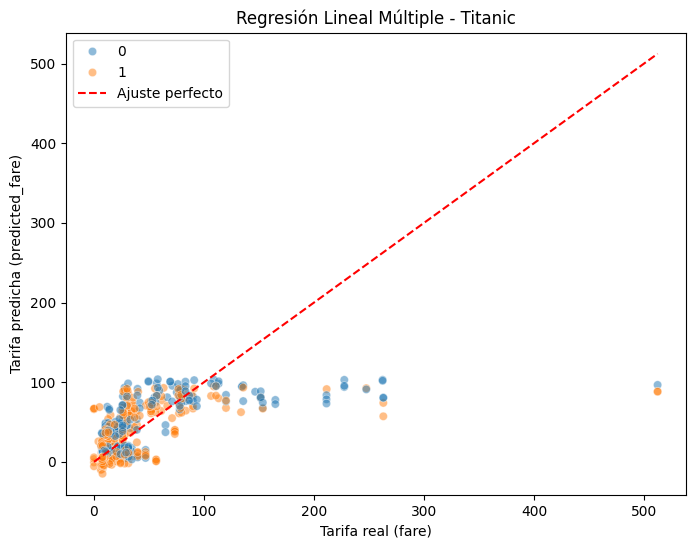

In [10]:

# Paso 1: Preparar los datos

import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Cargar el dataset Titanic desde seaborn
df = sns.load_dataset("titanic")

# Seleccionar solo las variables relevantes
df = df[['fare', 'age', 'pclass', 'sex', 'embarked']]

# Eliminar filas con valores nulos
df = df.dropna()

# Revisar los tipos de datos
print("Tipos de datos originales:")
print(df.dtypes)
print("\nPrimeras filas del DataFrame:")
print(df.head())

# Paso 2: Codificar las variables categóricas

# Crear variables dummy (0/1) para las variables categóricas
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

print("\nTipos de datos después de crear variables dummy:")
print(df.dtypes)

# Paso 3: Convertir booleanas a enteros (1/0)

# Detectar columnas booleanas y convertirlas a int
for col in df.select_dtypes(include='bool').columns:
    df[col] = df[col].astype(int)

print("\nTipos de datos después de convertir booleanas a enteros:")
print(df.dtypes)

# Paso 4: Definir variables predictoras o independiente (X) y variable objetivo o dependiente (y)

# Variable objetivo o dependiente
y = df['fare']

# Variables predictoras o independiente
X = df.drop(columns=['fare'])

# Agregar constante para calcular el intercepto β₀
X = sm.add_constant(X)

print("\nVariables independientes (X):")
print(X.head())
print("\nVariable dependiente (y):")
print(y.head())


# Paso 5: Ajustar el modelo de regresión lineal múltiple

# Crear y entrenar el modelo OLS (Ordinary Least Squares)
modelo = sm.OLS(y, X).fit()

# Mostrar el resumen del modelo
print("\nResumen estadístico del modelo:")
print(modelo.summary())


# Paso 6: Visualizar el ajuste del modelo

# Generar predicciones
df['predicted_fare'] = modelo.predict(X)

# Crear gráfica de dispersión: valores reales vs. predichos
plt.figure(figsize=(8,6))
#plt.scatter(df['fare'], df['predicted_fare'], color='blue', alpha=0.6, label='Datos')
# valores reales
sns.scatterplot(
    x=df['fare'],
    y=df['predicted_fare'],
    color='blue',
    hue=df['sex_male'],
    alpha=0.5)


plt.plot([df['fare'].min(), df['fare'].max()],
         [df['fare'].min(), df['fare'].max()],
         color='red', linestyle='--', label='Ajuste perfecto')

plt.title("Regresión Lineal Múltiple - Titanic")
plt.xlabel("Tarifa real (fare)")
plt.ylabel("Tarifa predicha (predicted_fare)")
plt.legend()
plt.show()


# **Interpretación general del modelo**

Este resumen muestra los resultados de una regresión lineal múltiple (OLS) donde queremos predecir el precio del boleto (fare) de los pasajeros del Titanic en función de varias variables: la edad, la clase del boleto (pclass), el sexo y el puerto de embarque (embarked).

El modelo nos indica qué factores influyen realmente en el precio del boleto y en qué dirección.

# **¿Qué tan bien explica el modelo los datos?**

R² = 0.346 → El modelo explica aproximadamente el 34.6 % de la variación en los precios de los boletos.
Esto quiere decir que un tercio del comportamiento del precio puede entenderse a partir de las variables que usamos, y el resto se debe a otros factores no incluidos (por ejemplo, tipo de camarote, si viajaba solo, etc.).


F-statistic = 74.81 y Prob (F-statistic) = 6.89e-63 → El modelo es estadísticamente significativo, lo que confirma que al menos una de las variables elegidas realmente influye en el precio del boleto.

# **Conclusión**

Este modelo nos permite entender qué tipo de pasajero pagaba más o menos por su boleto.
Aunque no explica todo el comportamiento de los precios, sí revela patrones muy claros:

* La clase social fue el factor más determinante.

* El sexo y el puerto de embarque también influyeron significativamente.

* La edad tuvo un efecto pequeño, pero real.

En términos prácticos, el modelo sirve para estimar tendencias generales, pero no para predecir con exactitud el precio de cada boleto individual, ya que existen otros factores fuera del modelo que también afectan.